In [27]:
suppressMessages({
    library(dplyr)
    library(ggplot2)
    library(tidyverse)
    library(slider)
    library(pROC)
    library(xgboost)
    library(Matrix)
    library(maps)
    library(viridis)
})

# Overview and Introduction

As seasonal issues due to climate change are gaining attention across the globe, knowing how to analyse climate data becomes more important.  We take a look at a sample of wildfires from a dataset on kaggle to predict when a large wildfire may occur, and what factors might coincide with large fires.  Predicting likelihood of a large fire outcome is important because knowing when a larger fire might happen could save lives.

The dataset we are working with contains a database of 1.88 million wildfires that occurred in the U.S. from 1992 to 2015. This database comes from the national Fire Program Analysis (FPA) system and the full dataset contains 39 variables, with our sample containing 100,000 observations.

Each observation in the core set is one wildfire event that contains elements such as GPS data for ignition location, size of the fire, and discovery date.

Most recorded fires tend to be small, so if we modeled them all together that would skew the data towards small fires and we would not be able to focus on meaningfully large fires.   We will therefore focus our attention on notable fires, which we define as having a final burned area of larger than 300 acres.  When then aggregate the categorical data into the temporal panel over the spatial data.

This project develops predictive model for wildfires incidence in the United States using the aforementioned data.  Our exploratory data analysis shows how wildfire activity is concentrated in the Western Coastal, Northwestern, Southeastern, and some Southern areas of the United States.  It also shows clear seasonal patterns over the course of a year, as well as increased incidence in relation to recent fires. Two approaches to modeling were attempted:  a more linear, logistic regression model and a non-linear decision tree model known as XGBoost.  To prevent data leakage, we used time aware cross validation, with area under the curve ROC (AUC) as our primary metric.

AUC values revealed that XGBoost showed consistently better performance across all validation years.  These results suggest that for something like wildfire incidence, which must take time and location into account, as well as recent incidents, a nonlinear approach is best.

In [28]:
wildfires <- read_csv("wildfires_sample_100k.csv") %>% 
  select(FIRE_YEAR, DISCOVERY_DOY, FIRE_SIZE, LATITUDE, LONGITUDE, STATE) %>%
  mutate(STATE = as.factor(STATE))



Rows: 100000 Columns: 39
── Column specification ──────────────────────────────────────────────────────────────────────────────────────────────────────────────
Delimiter: ","
chr (27): FPA_ID, SOURCE_SYSTEM_TYPE, SOURCE_SYSTEM, NWCG_REPORTING_AGENCY, ...
dbl (12): OBJECTID, FOD_ID, FIRE_YEAR, DISCOVERY_DATE, DISCOVERY_DOY, STAT_C...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


# 1. Data Preprocessing

The wildfire data is prepared for analysis into a spatial and time specific dataset.

Our task is to predict whether at least one notable wildfire will occur within a geographic grid cell during the following month.  Our chosen spatial unit is a 1 degree by 1 degree latitude x longitude grid cell, and the chosen temporal unit is a month.  The fire size will be considered notable if the total area burned is equal to or larger than 300 acres.  $fire_next_month$, the outcome, will equal 1 if there is at least wildfire of note in the grid cell that month t+1, and 0 if otherwise.  The predictors are FIRE_YEAR, DISCOVERY_DOY (day of year), FIRE_SIZE, LATITUDE, LONGITUDE, and STATE.


In [29]:
fires <- wildfires %>% 
    mutate(FIRE_DATE = as.Date(paste(FIRE_YEAR, DISCOVERY_DOY, sep = "-"), format = "%Y-%j"),
          YEAR = year(FIRE_DATE),
          MONTH = month(FIRE_DATE))

In [30]:
# filtering out fires less than 300
notable_threshold_acres <- 300
notable_fires <- fires %>%
  filter(FIRE_SIZE >= notable_threshold_acres)

In [31]:
notable_fires <- notable_fires %>%
  mutate(lat_bin = floor(LATITUDE), lon_bin = floor(LONGITUDE), ym = YEAR * 100 + MONTH)

# table with lat_bin, lon_bin, num_fires, and fire_this_month outcome
grid_month_fire <- notable_fires %>%
    group_by(lat_bin, lon_bin, ym) %>%
    summarise(n_fires = n(), fire_this_month = 1L, .groups = "drop")
head(grid_month_fire)

lat_bin,lon_bin,ym,n_fires,fire_this_month
<dbl>,<dbl>,<dbl>,<int>,<int>
17,-67,200407,1,1
18,-68,200906,1,1
18,-67,200503,1,1
19,-156,199210,1,1
19,-156,199910,1,1
19,-156,200706,1,1


For each grid cell and month, we defined a binary indicator, fire_this_month, which is 1 if a notable fire occurs within the grid cell and month, and 0 if there are none.  Because we are making a prediction, we also define the outcome fire_next_month as the binary indicator of next month's possible fire of note within the temporal-spatial unit.  Predictors measured up to month t will indicate whether a notable fire occurs in month t+1.

In [32]:
# ---- Build panel (all grid cells that appear at least once) ----
all_grids <- grid_month_fire %>% distinct(lat_bin, lon_bin)

# Generate a safe monthly sequence using actual dates
start_date <- ymd(paste0(min(grid_month_fire$ym) %/% 100, "-", min(grid_month_fire$ym) %% 100, "-01"))
end_date   <- ymd(paste0(max(grid_month_fire$ym) %/% 100, "-", max(grid_month_fire$ym) %% 100, "-01"))

all_months <- tibble(date = seq.Date(start_date, end_date, by = "month")) %>%
  mutate(year = year(date), month = month(date), ym = year * 100 + month) %>%
  select(ym, year, month)

# Full panel = grid × month

panel <- crossing(all_grids, all_months) %>%
  left_join(grid_month_fire, by = c("lat_bin", "lon_bin", "ym")) %>%
  mutate(n_fires = coalesce(n_fires, 0), fire_this_month = coalesce(fire_this_month, 0))
glimpse(panel)

Rows: 148,092
Columns: 7
$ lat_bin         <dbl> 17, 17, 17, 17, 17, 17, 17, 17, 17, 17, 17, 17, 17, 17…
$ lon_bin         <dbl> -67, -67, -67, -67, -67, -67, -67, -67, -67, -67, -67,…
$ ym              <dbl> 199201, 199202, 199203, 199204, 199205, 199206, 199207…
$ year            <dbl> 1992, 1992, 1992, 1992, 1992, 1992, 1992, 1992, 1992, …
$ month           <dbl> 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 1, 2, 3, 4, 5, …
$ n_fires         <dbl> 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, …
$ fire_this_month <dbl> 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, …


In [33]:
panel <- panel %>%
  arrange(lat_bin, lon_bin, ym) %>%
  group_by(lat_bin, lon_bin) %>%
  mutate(fire_next_month = lead(fire_this_month, n = 1L)) %>%
    ungroup() %>%  filter(!is.na(fire_next_month))

table(panel$fire_next_month)


     0      1 
146265   1311 

In [34]:
mode_state <- function(x) {
    ux <- unique(x)
    ux[which.max(tabulate(match(x, ux)))]
}

grid_state <- notable_fires %>%
  group_by(lat_bin, lon_bin) %>%
  summarise(state = mode_state(STATE), .groups = "drop")

panel <- panel %>%
  left_join(grid_state, by = c("lat_bin","lon_bin"))

panel %>% select(state) %>% summary

     state      
 AK     :17732  
 TX     :16016  
 CA     :10582  
 MT     : 8294  
 NM     : 8294  
 OR     : 6578  
 (Other):80080  

# 2. Exploratory Data Analysis

In [35]:
wildfires <- read_csv("wildfires_sample_100k.csv")
x <- colSums(is.na(wildfires))
x[x > 0]

Rows: 100000 Columns: 39
── Column specification ──────────────────────────────────────────────────────────────────────────────────────────────────────────────
Delimiter: ","
chr (27): FPA_ID, SOURCE_SYSTEM_TYPE, SOURCE_SYSTEM, NWCG_REPORTING_AGENCY, ...
dbl (12): OBJECTID, FOD_ID, FIRE_YEAR, DISCOVERY_DATE, DISCOVERY_DOY, STAT_C...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


LOCAL_FIRE_REPORT_ID       LOCAL_INCIDENT_ID               FIRE_CODE 
                  77654                   43621                   82817 
              FIRE_NAME ICS_209_INCIDENT_NUMBER            ICS_209_NAME 
                  51227                   98634                   98634 
                MTBS_ID          MTBS_FIRE_NAME            COMPLEX_NAME 
                  99423                   99423                   99751 
         DISCOVERY_TIME               CONT_DATE                CONT_DOY 
                  46972                   47483                   47483 
              CONT_TIME                  COUNTY               FIPS_CODE 
                  51813                   35991                   35991 
              FIPS_NAME 
                  35991

There are several variables that contain only administrative identifiers and metadata that are missing a significant number of values. Incident identifiers such as ICS_209_INCIDENT_NUMBER and MTBS_ID are missing for over 90% of the observations. However, these are not meaningful to our prediction needs, so our analysis focuses on six key variables that are relevant for predicting large wildfires (temporal data and spatial data) : FIRE_YEAR, DISCOVERY_DOY, FIRE_SIZE, LATITUDE, LONGITUDE, and STATE.

In [36]:
wildfires <- wildfires %>%
    mutate(FIRE_DATE = as.Date(paste(FIRE_YEAR, DISCOVERY_DOY, sep = "-"), format = "%Y-%j"))
# range(wildfires$FIRE_DATE, na.rm = TRUE)
# wildfires %>% select(FIRE_YEAR, DISCOVERY_DOY) %>% head()

FIRE_YEAR,n_fires
<dbl>,<int>
1992,3621
1993,3169
1994,4073
1995,3774
1996,3903
1997,3230


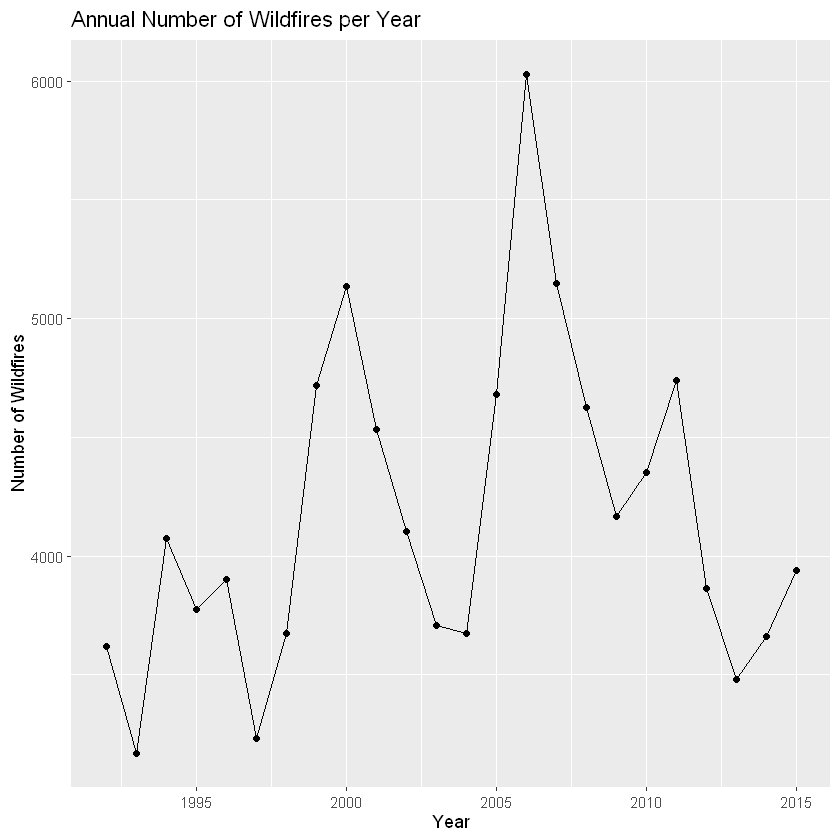

In [37]:
# Annual fire counts and plot

# count fires by year, new column = n_fires
annual_fires <- wildfires %>% count(FIRE_YEAR, name = "n_fires")
head(annual_fires)

# plot annual number of wildfires per year

ggplot(annual_fires, aes(x = FIRE_YEAR, y = n_fires)) + geom_line() + geom_point() +
    labs(title = "Annual Number of Wildfires per Year", x = "Year", y = "Number of Wildfires")

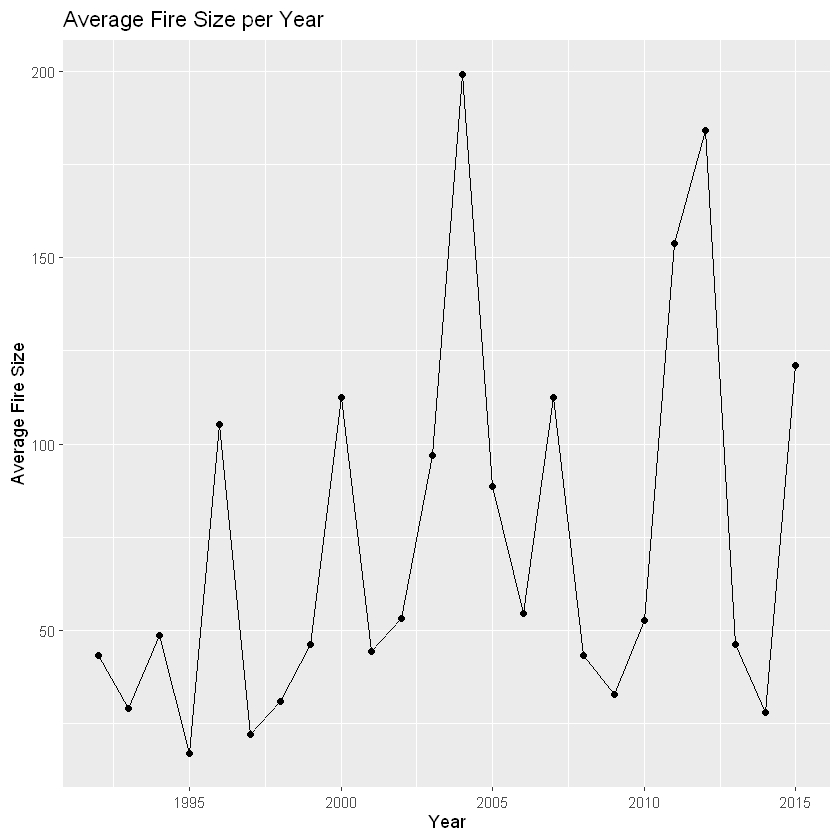

In [38]:
# average size of fire per year

avg_fsize_per_year <- wildfires %>% group_by(FIRE_YEAR) %>% summarise(avg_fire_size = mean(FIRE_SIZE, na.rm = TRUE),.groups = "drop")

ggplot(avg_fsize_per_year, aes(x = FIRE_YEAR, y = avg_fire_size)) + geom_line() + geom_point() +
    labs(title = "Average Fire Size per Year", x = "Year", y = "Average Fire Size")
    

    Year to year, the number of wildfires varies substantially, with noticeable spikes from 1998 to 2004 and 2004 - 2008.  The largest of these peaks occurs in 2006 with other local increases around 2000 and in 2011, but there is no clear upward or downward trend. The average fire size also fluctuates quite a bit, with a few extreme spikes around 2004 and 2012. This also suggests that average fire size could correspond to a small number of very large fires.  Years with unusually large average in fire size don't always correspond to years with highest number of fires, which could suggest that frequency and fire size are driven by different underlying factors.

In [39]:
# counts per state
count_per_state <- wildfires %>% count(STATE, name = "n_fires") %>% arrange(desc(n_fires))
top_10_states <- head(count_per_state, 10) # top 10 states (sliced for later)
top_10_states

STATE,n_fires
<chr>,<int>
CA,10089
GA,8899
TX,7545
NC,5815
FL,4814
NY,4353
SC,4320
MS,4246
AZ,3722


California has an unusually high frequency of wildfires per year.

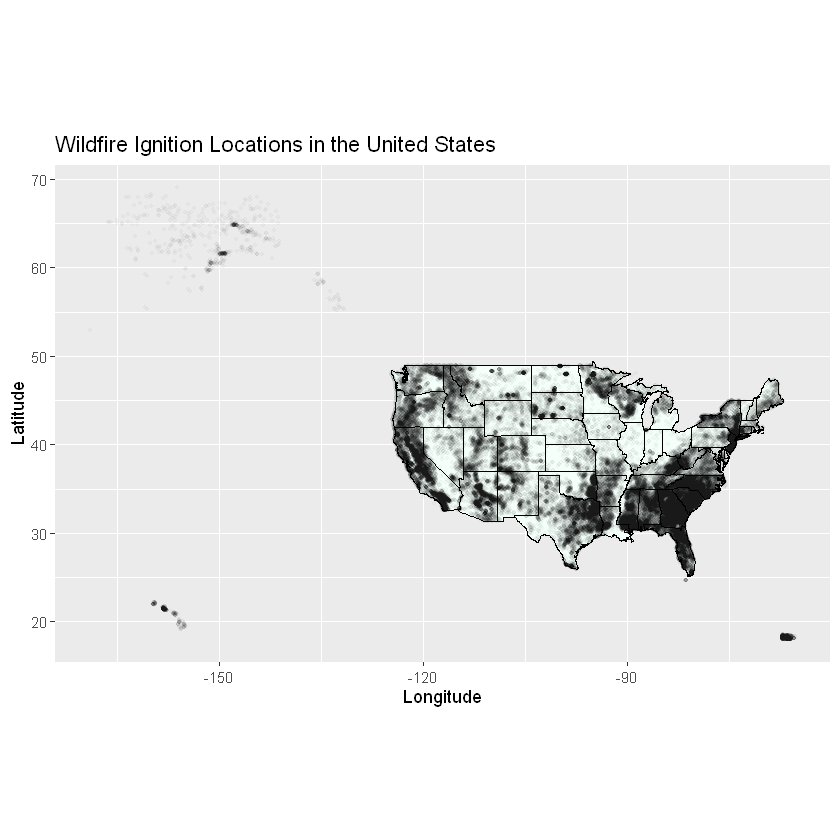

In [40]:
#overlay points on a simple US map

us_map <- map_data("state")

ggplot() + geom_polygon(data = us_map, aes(x = long, y = lat, group = group), fill = "mintcream", color = "black")+ 
    geom_point(data = wildfires, aes(x = LONGITUDE, y = LATITUDE), alpha = 1/50, size = 0.8) +
    coord_fixed(1.3) +
  labs(title = "Wildfire Ignition Locations in the United States", x = "Longitude", y = "Latitude")

    Ignition points on this map have heavy clusters near the Southeastern and Western parts of the greater US, with greater sparsity in the central and midwestern part of the US. There is especially high concentration of ignition points clustered near Florida, as well a huge concentration along the coast of California. This pattern suggest that ignition point likelihood varies by geographic location.

In [ ]:
# histogram(s) of FIRE_SIZE
# needs log scale fix for better visualization
wildfires %>% ggplot(aes(x = FIRE_SIZE)) + geom_histogram(bins = 50) + scale_x_log10()+
    labs(title = "Distribution of Fire Size(log scale)", x = "FIRE SIZE (acres on the log scale)", y = "COUNT")

In [ ]:
# summary statistics
size_summary <- wildfires %>%
    summarise(
        median_size = median(FIRE_SIZE, na.rm = TRUE),
        p90_size = quantile(FIRE_SIZE, 0.90, na.rm = TRUE),
        p99_size = quantile(FIRE_SIZE, 0.99, na.rm = TRUE))

size_summary

The distribution shows that about half of fires are 1 acre or smaller, 90% of fires are 17 acres or smaller and 99% are 480 acres or smaller, which also means that only 10% are bigger than 17 acres, or 1% bigger than 480 acres. Our histogram has a heavily right-skewed distribution. If median fire size is around 1 acre, then most fires are relatively small. But because of the 90 and 99th percentile fires covering 17 and then 480 acres, we can tell that a small percentage of the fires account for large areas of burned ground. In distributions with heavy tails like this one, log 10 scaling we used improves visualization.


In [ ]:
top10 <- wildfires %>% count(STATE, sort = TRUE) %>% slice_head(n =10) %>% pull(STATE) #pulling top 10 counts by state)
state_year_summary <- wildfires %>%
    group_by(STATE, FIRE_YEAR) %>%
    summarise(
        median_size = median(FIRE_SIZE, na.rm = TRUE),
        mean_size = mean(FIRE_SIZE, na.rm = TRUE),
        n_fires = n(),
        .groups = "drop")
state_year_summary %>% filter(STATE %in% top10) %>%
    ggplot(aes(x = FIRE_YEAR, y = median_size, color= STATE)) +
    geom_line(size = 0.8) + scale_y_log10() + scale_color_viridis_d() +
    labs(title = "Median Fire Size over Time (for top 10 states)", x = "YEAR", y = "MEDIAN FIRE SIZE (Log 10)",
         color = "State") + theme_minimal()


We plot median fire size over all years of the data set for the ten states with highest fire sizes. This gives us a clearer look into how wildfire severity fluctuates in different parts of the United States.  There are no clear upward or downward trends here.  Instead, there are local spikes in certain years, which suggests again that wildfire events are driven by occasional unusual fire events rather than any long-term linear patterns.  It also seems that coastal states and particular southern ones tend to have larger fire sizes than most inland ones, which suggests that geographic variation and environmental factors have a lot to do with fire size.

## Seasonality : Cyclical month encoding
Reason: December (12) and January (1) are close in reality, but far numerically.

In [43]:
panel <- panel %>%
  mutate(month_sin = sin(2 * pi * month / 12), month_cos = cos(2 * pi * month / 12))

panel %>% select(month_sin, month_cos) %>% head

month_sin,month_cos
<dbl>,<dbl>
5.000000e-01,8.660254e-01
8.660254e-01,5.000000e-01
1.000000e+00,6.123234e-17
8.660254e-01,-5.000000e-01
5.000000e-01,-8.660254e-01
1.224647e-16,-1.000000e+00


In [44]:
######### aggregate fire size within grid cell/year month #########
grid_fire_size <- notable_fires %>%
    group_by(lat_bin, lon_bin, ym) %>%
    summarise(fire_size = mean(FIRE_SIZE, na.rm = TRUE), .groups = "drop")

######### join tables

panel <- panel %>%
  left_join(grid_fire_size, by = c("lat_bin","lon_bin", "ym")) %>%
  mutate(fire_size = coalesce(fire_size, 0))



panel <- panel %>%
  arrange(lat_bin, lon_bin, ym) %>% 
  group_by(lat_bin, lon_bin) %>%
  mutate(
    fire_lag12 = lag(n_fires, 12, default = 0),
    fire_roll3 = slide_dbl(lag(n_fires, 1, default = 0), sum, .before = 2, .complete = FALSE),
    fire_roll12 = slide_dbl(lag(n_fires, 1, default = 0), sum, .before = 11, .complete = FALSE),
    size_roll3 = slide_dbl(lag(fire_size, 1, default = 0), sum, .before = 2, .complete = FALSE),
    size_roll12 = slide_dbl(lag(fire_size, 1, default = 0), sum, .before = 11, .complete = FALSE)
  ) %>%
  ungroup()

######### selection of feate

panel %>% 
  select(n_fires, fire_lag12, fire_roll3, fire_roll12, size_roll3, size_roll12) %>%
  summary

    n_fires           fire_lag12         fire_roll3       fire_roll12    
 Min.   :0.000000   Min.   :0.000000   Min.   :0.00000   Min.   :0.0000  
 1st Qu.:0.000000   1st Qu.:0.000000   1st Qu.:0.00000   1st Qu.:0.0000  
 Median :0.000000   Median :0.000000   Median :0.00000   Median :0.0000  
 Mean   :0.009351   Mean   :0.008972   Mean   :0.02783   Mean   :0.1089  
 3rd Qu.:0.000000   3rd Qu.:0.000000   3rd Qu.:0.00000   3rd Qu.:0.0000  
 Max.   :3.000000   Max.   :3.000000   Max.   :5.00000   Max.   :6.0000  
   size_roll3        size_roll12    
 Min.   :     0.0   Min.   :     0  
 1st Qu.:     0.0   1st Qu.:     0  
 Median :     0.0   Median :     0  
 Mean   :   129.1   Mean   :   494  
 3rd Qu.:     0.0   3rd Qu.:     0  
 Max.   :344833.0   Max.   :344833  

Recent incidence of wildfires can also provide information about risk in the short term.  For this reason we constructed variables that would capture a lagged and rolling effect of fire activity in the recent past. This includes notable fires that happened about 12 months earlier as well as 3 month and 12 month rolling totals for frequency and fire size.  These rolling variables are only based on past months and do not include predictive information like next month's counts.

### Dataset Summary Table

In [45]:
dataset_summary <- tibble(
  n_rows = nrow(panel),
  year_min = min(panel$year),
  year_max = max(panel$year),
  spatial_unit = "1° x 1° lat-lon grid (floor bins)",
  temporal_unit = "monthly",
  outcome = "fire_next_month = 1 if any notable fire occurs in grid cell next month",
  predictors = "lat_bin, lon_bin, state, month_cos, month_sin, year, 
    n_fires, fire_lag12, fire_roll3, fire_roll12, 
    size_roll3, size_roll12"
)

dataset_summary

n_rows,year_min,year_max,spatial_unit,temporal_unit,outcome,predictors
<int>,<dbl>,<dbl>,<chr>,<chr>,<chr>,<chr>
147576,1992,2015,1° x 1° lat-lon grid (floor bins),monthly,fire_next_month = 1 if any notable fire occurs in grid cell next month,"lat_bin, lon_bin, state, month_cos, month_sin, year, n_fires, fire_lag12, fire_roll3, fire_roll12, size_roll3, size_roll12"


This final model includes 147576 observations, from years 1992 to 2015, each in a 1 degree by 1 degree spatial grid cell with includes spatial, temporal and measures of recent fire activity like the lag counts and rolling variables we mentioned above (fire_lag12, fire_roll3, fire_roll12, size_roll3, and size_roll12).

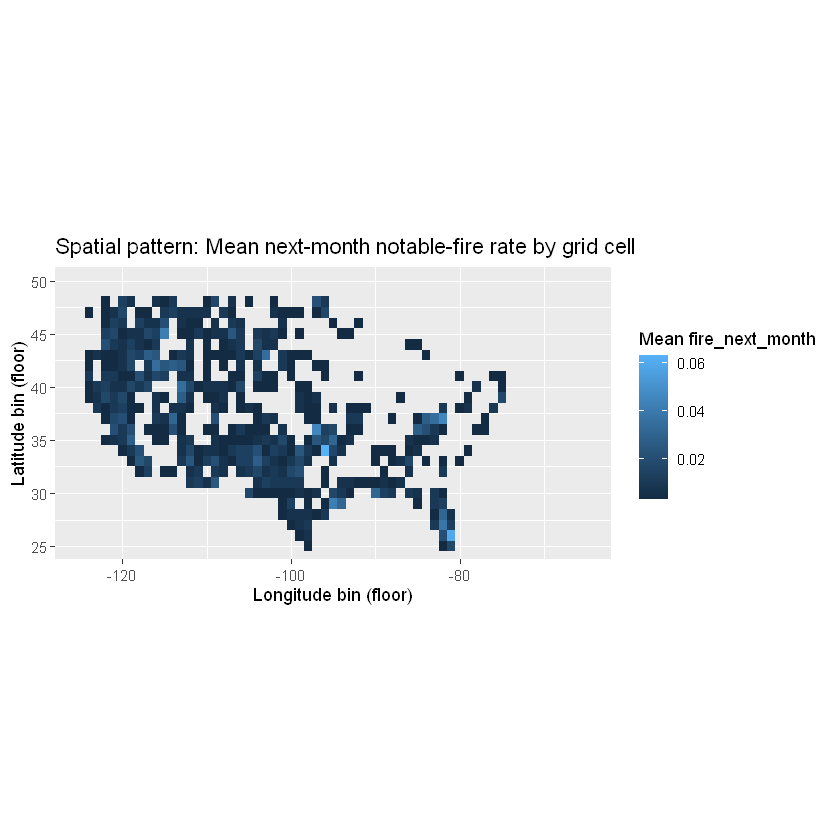

In [46]:
######### leaving EDA mean fire probability map here #########
eda_spatial <- panel %>%
    group_by(lat_bin, lon_bin) %>%
    summarise(fire_rate = mean(fire_next_month), .groups = "drop")

ggplot(eda_spatial, aes(x = lon_bin, y = lat_bin, fill = fire_rate)) +
  coord_quickmap(xlim = c(-125, -65), ylim = c(25, 50)) + 
  geom_tile() +
  labs(
    title = "Spatial pattern: Mean next-month notable-fire rate by grid cell",
    x = "Longitude bin (floor)",
    y = "Latitude bin (floor)",
    fill = "Mean fire_next_month"
  )

This is a heatmap of mean probability of a fire event of note (in the next month) in regards to geographic location.  There is higher mean probability of a predicted fire for western coastal areas and Northwest, Southwestern (near Texas) and parts of the Southeastern US and Florida.  The data suggests that geographic location continues to be a meaningful predictor.

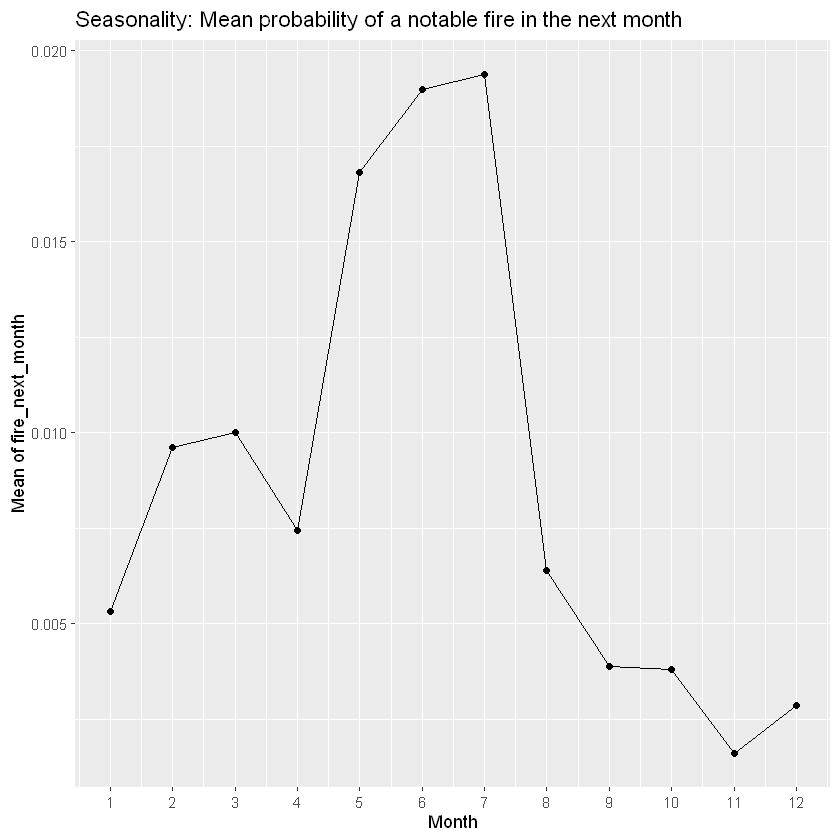

In [47]:
eda_month <- panel %>%
  group_by(month) %>%
  summarise(mean_fire_next_month = mean(fire_next_month), .groups = "drop")

ggplot(eda_month, aes(x = month, y = mean_fire_next_month)) +
  geom_line() +
  geom_point() +
  scale_x_continuous(breaks = 1:12) +
  labs(
    title = "Seasonality: Mean probability of a notable fire in the next month",
    x = "Month",
    y = "Mean of fire_next_month"
  )

To examine temporal patterns, we first compute the average value of fire_next_month for each month of the year. Because it is a binary variable, its average can be interpreted as the probability that at least one notable fire occurs within the following month for any given grid cell.

The results have clear seasonal patterns. Late spring and summer months have the highest chance of a notable fire event occurring while fall and winter months have the lowest probability of a notable fire event.  During the highest risk period, probability of such a fire climbs to 1.7 - 1.9%, much higher than other seasons. After July going into August there is a very steep decline in chance of fire probability, which might coincide with the advent of cooler and moister weather fronts.  There is a clear cyclical pattern in the probability of a notable fire in these spring and summer months, so it would be wise to include in the model. Our monthly panel variable was transformed with sin and cosine functions, which preserves the cyclical relationship between spring - summer and fall-winter.

# 3. Modeling
Our exploratory data analysis shows that there are strong spatial patterns in wildfire incidence, as well as seasonal cycling.  We also saw some prediction patterns that coincided with recent fire activity. This encourages the use of predictors that incorporate geography, seasonal data, and lagged fire activity.

For modeling, we will keep the previously stated predictors, and convert the outcome variable fire_next_month into a categorical variable so that the model will treat it as a binary outcome (fire vs. no fire).  As previously stated, each observation represents this outcome for a single grid cell/month pair.  Spatial location predictors are lat_bin, lon_bin and state, while temporal predictors are month_sin, month_cos and year.  Rolling variables include summaries of recent fire activities such as fire_lag12, fire_roll3, fire_roll12, size_roll3, and size_roll12.

In [48]:
model_df <- panel %>%
  mutate(fire_next_month = factor(fire_next_month, levels = c(0, 1))) %>%
  select(fire_next_month, lat_bin, lon_bin, state, 
         month_cos, month_sin, year, 
         n_fires, fire_lag12, fire_roll3, fire_roll12, size_roll3, size_roll12)
glimpse(model_df)

Rows: 147,576
Columns: 13
$ fire_next_month <fct> 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, …
$ lat_bin         <dbl> 17, 17, 17, 17, 17, 17, 17, 17, 17, 17, 17, 17, 17, 17…
$ lon_bin         <dbl> -67, -67, -67, -67, -67, -67, -67, -67, -67, -67, -67,…
$ state           <fct> PR, PR, PR, PR, PR, PR, PR, PR, PR, PR, PR, PR, PR, PR…
$ month_cos       <dbl> 8.660254e-01, 5.000000e-01, 6.123234e-17, -5.000000e-0…
$ month_sin       <dbl> 5.000000e-01, 8.660254e-01, 1.000000e+00, 8.660254e-01…
$ year            <dbl> 1992, 1992, 1992, 1992, 1992, 1992, 1992, 1992, 1992, …
$ n_fires         <dbl> 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, …
$ fire_lag12      <dbl> 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, …
$ fire_roll3      <dbl> 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, …
$ fire_roll12     <dbl> 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, …
$ size_roll3      <dbl> 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, …
$ size_roll12 

# 4. Model Fitting and Validation

Using our curated data, we build a logistic regression model, the gradient decision tree model (XGBoost) suggested by the instructors.  We also used time-aware cross validation rather than random train-test splitting because our wildfire data is temporal.  If we used random splits, we could mix future observations into the training set and cause data leakage, since the model could learn from data that occurs later in time.  So instead, models are trained on all preceding years and then evaluated on the following year.  The area under the ROC curve (AUC) was used as our metric to compare the two models.  Logistic regression serves as our baseline to estimate coefficients once per fold and then compute AUC, while XGBoost is a more complicated process, building boosted decision trees within each fold over multiple rounds.

In [53]:
years_sorted <- sort(unique(model_df$year))
min_train_years <- 3

feat_formula <- fire_next_month ~ lat_bin + lon_bin + state + month_cos + month_sin + year +
  n_fires + fire_lag12 + fire_roll3 + fire_roll12 + size_roll3 + size_roll12

fold_results <- tibble(
    train_end_year = years_sorted[(min_train_years):(length(years_sorted) - 2)],
    valid_year = years_sorted[(min_train_years + 1):(length(years_sorted) - 1)]) %>%
      mutate(
      # Logistic Regression
      auc_glm = map2_dbl(train_end_year, valid_year, function(tr_end, va_year) {
          train <- model_df %>% filter(year <= tr_end)
          valid <- model_df %>% filter(year == va_year)


        fit <- glm(feat_formula, data = train, family = binomial())
        p_hat <- predict(fit, newdata = valid, type = "response")

          #########

          roc_obj <- roc(response = valid$fire_next_month, predictor = p_hat, quiet = TRUE)
          as.numeric(auc(roc_obj))}),
      
      # XGboost
      
auc_xgb = map2_dbl(train_end_year, valid_year, function(tr_end, va_year) {
  train <- model_df %>% filter(year <= tr_end)
  valid <- model_df %>% filter(year == va_year)

  x_train <- model.matrix(fire_next_month ~ . - 1, data = train)
  x_valid <- model.matrix(fire_next_month ~ . - 1, data = valid)

  dtrain <- xgb.DMatrix(data = x_train, label = as.numeric(train$fire_next_month) - 1)
  dvalid <- xgb.DMatrix(data = x_valid, label = as.numeric(valid$fire_next_month) - 1)

  fit_xgb <- xgb.train(
    params = list(
      objective = "binary:logistic",
      eval_metric = "auc",
      max_depth = 4,
      eta = 0.1,
      subsample = 0.8,
      colsample_bytree = 0.8
    ),
    data = dtrain,
    nrounds = 100,
    verbose = 0
  )
    p_hat <- predict(fit_xgb, newdata = dvalid)
      roc_obj <- roc(response = valid$fire_next_month, predictor = p_hat, quiet = TRUE)
      as.numeric(auc(roc_obj))
})
      )

fold_results

train_end_year,valid_year,auc_glm,auc_xgb
<dbl>,<dbl>,<dbl>,<dbl>
1994,1995,0.6724591,0.7846537
1995,1996,0.7189820,0.8191473
1996,1997,0.7925032,0.8270017
1997,1998,0.7601058,0.8285830
1998,1999,0.6656930,0.7122292
1999,2000,0.7268648,0.8129933
2000,2001,0.7540398,0.8237241
2001,2002,0.7236125,0.8081852
2002,2003,0.7299050,0.8140915


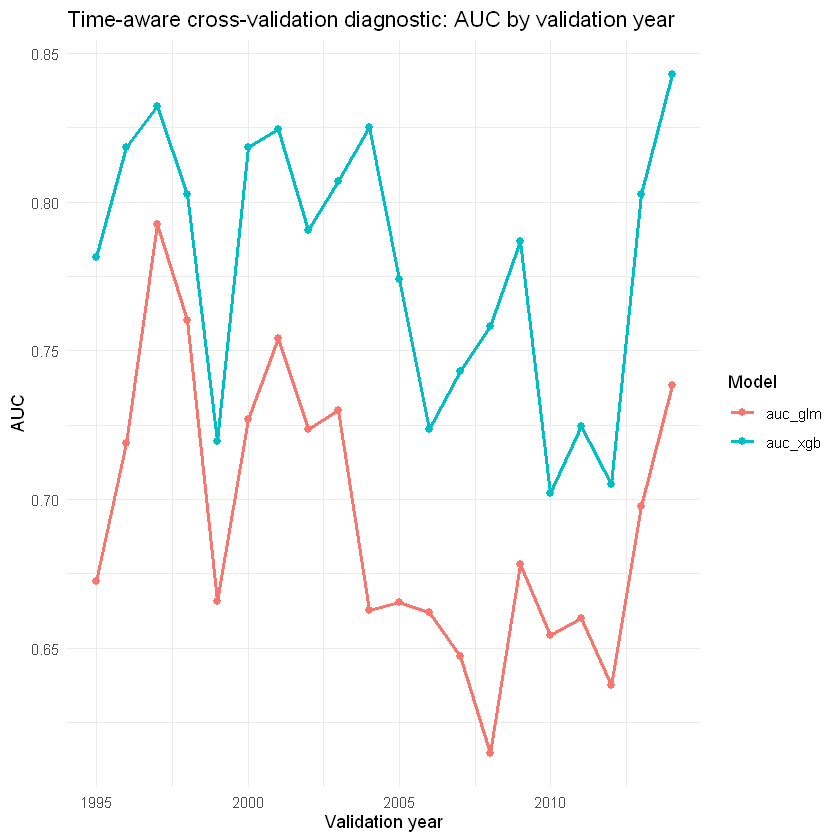

In [50]:
fold_long <- fold_results %>%
  pivot_longer(
    cols = c(auc_glm, auc_xgb),
    names_to = "model",
    values_to = "auc"
  )

ggplot(fold_long, aes(x = valid_year, y = auc, color = model)) +
  geom_line(linewidth = 1) +
  geom_point(size = 2) +
  labs(
    title = "Time-aware cross-validation diagnostic: AUC by validation year",
    x = "Validation year",
    y = "AUC",
    color = "Model"
  ) + 
  theme_minimal()

In [51]:
cat('Overall, XGboost outperforms logistic regression in AUC by ', 
    round(mean(fold_results$auc_xgb) / mean(fold_results$auc_glm) * 100, 2) - 100, "%", sep= '')

Overall, XGboost outperforms logistic regression in AUC by 12.4%

# 5. Summary

Incidence of wildfires in this dataset show a strong spatial concentration in Western, Northwestern, and Texas area, and Southeastern areas of the United States.  Seasonally, there is a higher mean probability of fire events during the late Spring and Summer months, with a marked drop in Fall-Winter.  Data was aggregated into a grid-month panel with lagged and rolling historical fire data predictors in order to compare a logistic regression model against the XGBoost model (using time aware cross validation).  

Our final results show that for data with a temporal element, XGBoost consistently outperforms logistic regression over all validation years. The AUC curve is elevated at all positions in time, which suggests that the flexibility of XGBoost helps capture nonlinear relationships and interactions between predictors at a higher level than the simpler logistic regression model. For this prediction task, the boosted model simply outperforms the linear model.